# Importing Required Libraries

In [25]:
# Core libraries for data handling, numerical ops, and downloading market data
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# PyTorch: model building, training
import torch 
import torch.nn as nn
import torch.optim as optim

# Preprocessing and evaluation metric
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Device setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cpu')

#  Download price data

In [26]:
# NIFTY 50 Index
ticker = "^NSEI"  
df = yf.download(ticker, start="2020-01-01")
df_close = df[['Close']]

# Scale closing prices to help the LSTM train more effectively
scaler = StandardScaler()
df_close.loc[:, 'Close'] = scaler.fit_transform(df_close[['Close']])

# Keep only the Close column, since that's what we're modeling

[*********************100%***********************]  1 of 1 completed


In [7]:
df

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100
2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800
...,...,...,...,...,...
2026-07-27,23995.949219,24011.599609,23891.550781,23928.400391,319400
2026-07-28,23985.349609,24041.150391,23954.599609,23971.250000,437800


# Scale the data

<Axes: xlabel='Date'>

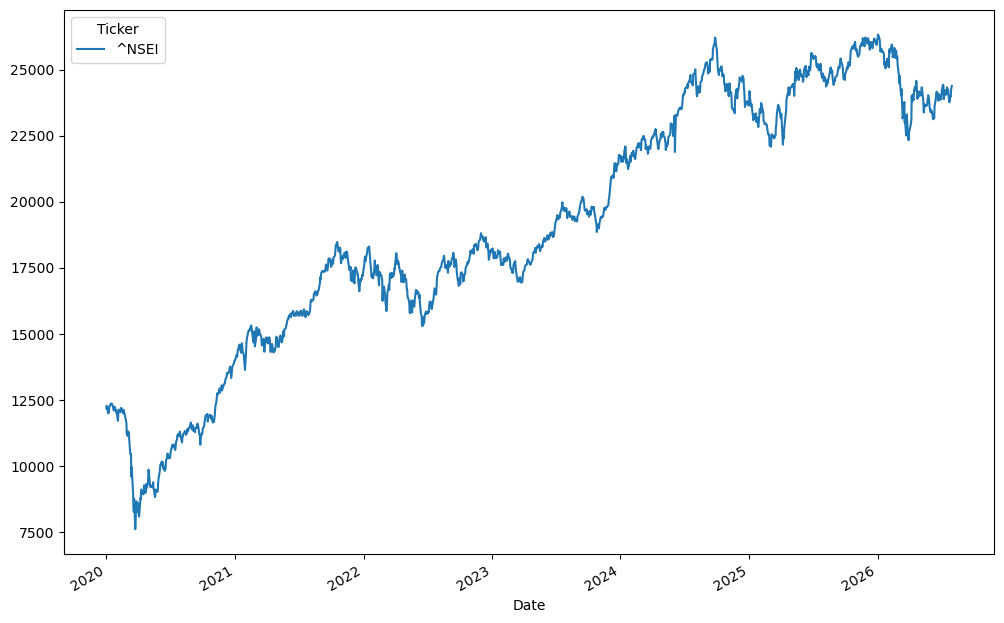

In [8]:
df.Close.plot(figsize = (12, 8))

In [9]:
# This is the scaler that actually gets used for training/inverse-transform later, fit it on df['Close'] directly (2D column, not a 1D Series)
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [164]:
df.Close

Ticker,^NSEI
Date,
2020-01-01,-1.435493
2020-01-02,-1.414666
2020-01-03,-1.426270
2020-01-06,-1.475069
2020-01-07,-1.462556
...,...
2026-07-24,0.984569
2026-07-27,1.032302
2026-07-28,1.030088


#  Build sliding-window sequences

In [10]:
# Build sliding windows: each sequence = seq_length consecutive scaled prices. The model will use the first (seq_length - 1) days to predict the last day.
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [11]:
data

array([[[-1.43607174],
        [-1.41524618],
        [-1.42684952],
        ...,
        [-1.45364922],
        [-1.46761289],
        [-1.45165424]],

       [[-1.41524618],
        [-1.42684952],
        [-1.47564444],
        ...,
        [-1.46761289],
        [-1.45165424],
        [-1.43216561]],

       [[-1.42684952],
        [-1.47564444],
        [-1.46313233],
        ...,
        [-1.45165424],
        [-1.43216561],
        [-1.43771138]],

       ...,

       [[ 1.03012282],
        [ 1.05029012],
        [ 1.06748125],
        ...,
        [ 0.98381348],
        [ 1.03154298],
        [ 1.02932891]],

       [[ 1.05029012],
        [ 1.06748125],
        [ 1.03512538],
        ...,
        [ 1.03154298],
        [ 1.02932891],
        [ 1.08465118]],

       [[ 1.06748125],
        [ 1.03512538],
        [ 1.05388313],
        ...,
        [ 1.02932891],
        [ 1.08465118],
        [ 1.09863606]]])

# Train / test split (80% / 20%), converted to torch tensors

In [12]:
# Chronological 80/20 split — train on the earlier 80% of sequences, test on the most recent 20% (no shuffling, since order matters in time series)
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
Y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
Y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

# Model definition — simple 2-layer LSTM regressor

In [13]:
class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Initialize hidden/cell state to zero for every forward pass
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        # Only need the output from the last time step for prediction
        out = self.fc(out[:, -1, :])
        return out

In [14]:
# input_dim=1 (just Close price), hidden_dim=32, 2 stacked LSTM layers, output_dim=1
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

# Training loop

In [16]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [17]:
num_epochs  = 200
for i in range(num_epochs):
    Y_train_pred = model(X_train)

    loss = criterion(Y_train_pred, Y_train)

    if i % 25 == 0:  
        print (i, loss.item())  # Track training progress every 25 epochs

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
        

0 0.9178688526153564
25 0.009935879148542881
50 0.003390961792320013
75 0.002607250353321433
100 0.0023855960462242365
125 0.0022570949513465166
150 0.0021559051238000393
175 0.0020683989860117435


# Evaluation

In [19]:
# Switch to eval mode (disables dropout/batchnorm behavior, though we don't use them here)
model.eval()

with torch.no_grad():
    Y_train_pred = model(X_train)
    Y_test_pred = model(X_test)
# Convert everything back from scaled values to real Nifty price units
Y_train_pred = scaler.inverse_transform(Y_train_pred.detach().cpu().numpy())
Y_train_actual = scaler.inverse_transform(Y_train.detach().cpu().numpy())
Y_test_pred = scaler.inverse_transform(Y_test_pred.detach().cpu().numpy())
Y_test_actual = scaler.inverse_transform(Y_test.detach().cpu().numpy())

In [20]:
# IMPORTANT: compare actual vs predicted in the SAME (real-price) units — using Y_train_actual/Y_test_actual here, not the raw scaled Y_train/Y_test
train_rmse = root_mean_squared_error(Y_train_actual[:, 0], Y_train_pred[:, 0])
test_rmse = root_mean_squared_error(Y_test_actual[:, 0], Y_test_pred[:, 0])

In [21]:
train_rmse

213.61019897460938

In [22]:
test_rmse

262.10223388671875

# Plot results: actual vs predicted price, and prediction error

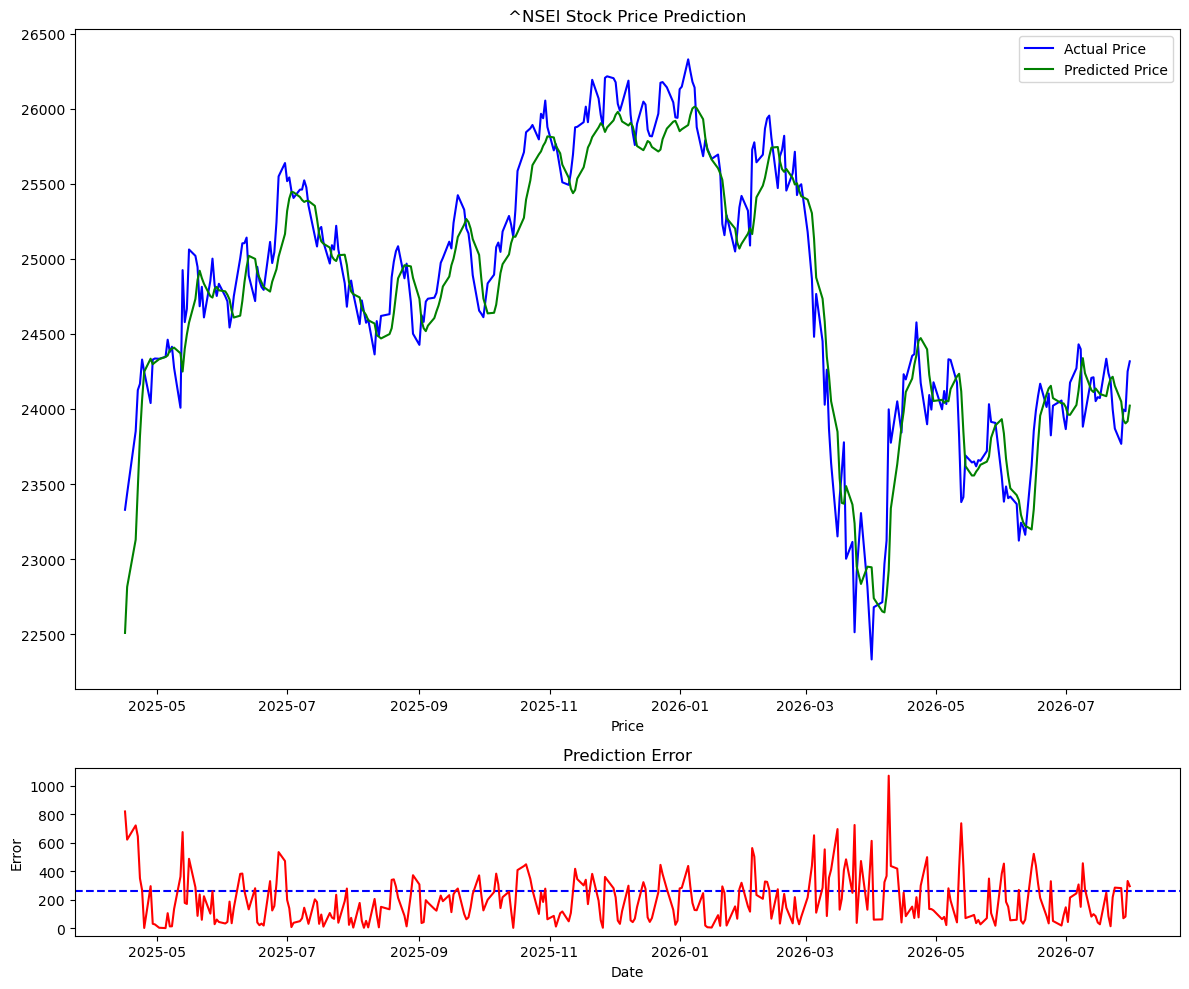

In [23]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

# Top panel: actual vs predicted price on the test set
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(Y_test_actual):].index, Y_test_actual, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(Y_test_actual):].index, Y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.xlabel('Price')

# Bottom panel: daily absolute error, with dashed line marking overall test RMSE
ax2 = fig.add_subplot(gs[3, 0])
ax2. axhline(test_rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(df.iloc[-len(Y_test_actual):].index, np.abs(Y_test_actual - Y_test_pred), 'r', label = 'Prediction Error')
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')

plt.tight_layout()
plt.show()